<h2>Project 4: Hacking Food & Nutrition</h2>
<h3>Group #5: Norman Borlaug — Tanzania</h3>

**Authors:** Rishitha Boddu, Omed Akbari, Grace Zhang, Daniel Do, Isha Chhabra

**Research question.** *How do food prices and household budgets shape nutrient adequacy among Tanzanian households, and how can policy interventions improve dietary outcomes?*

**Pipeline.** This notebook estimates a CFE food demand system from the 2019–20 and 2020–21 Tanzania National Panel Survey waves, maps predicted food demand into nutrient demand using a Tanzania food composition table, compares predicted intake to WHO/FAO Recommended Daily Allowances to identify deficiencies, and simulates two policy interventions: a 20% targeted price subsidy on iron-rich eggs and a 20% household cash transfer.


## 1. Environment setup

Use `%matplotlib inline` so plots render inside the notebook, and install `CFEDemands` if it is not already available. `cfe.regression` provides the demand-system estimation tools used below.

In [1]:
%matplotlib inline

import sys
import subprocess
import importlib.util

if importlib.util.find_spec("cfe") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "CFEDemands"])

## 2. Imports

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cfe.regression as rgsn

pd.set_option("display.max_columns", 30)

## 3. Locate the Tanzania data files

This searches the JupyterHub home directory for Tanzania CSVs and selects the folder containing the most matches. Avoiding hard-coded paths keeps the notebook reproducible across teammates.

In [3]:
HOME = Path.home()

print("Current working directory:")
print(Path.cwd())

all_csvs = sorted(HOME.rglob("*.csv"))
tanzania_csvs = [p for p in all_csvs if "tanzania" in p.name.lower()]

if len(tanzania_csvs) == 0:
    raise FileNotFoundError(
        "No Tanzania CSV files were found anywhere under home. "
        "Check that the CSVs are uploaded to JupyterHub."
    )

candidate_dirs = sorted(
    set(p.parent for p in tanzania_csvs),
    key=lambda d: sum(1 for p in tanzania_csvs if p.parent == d),
    reverse=True
)

DATA_DIR = candidate_dirs[0]
CSV_FILES = sorted(DATA_DIR.glob("*.csv"))

print("\nUsing data folder:")
print(DATA_DIR)
print("\nCSV files found:")
for p in CSV_FILES:
    print(" -", repr(p.name))

Current working directory:
/home/jovyan/Project 4 - Tanzania

Using data folder:
/home/jovyan/Project 4 - Tanzania

CSV files found:
 - 'Tanzania - FCT.csv'
 - 'Tanzania - Food Expenditures (2019-20).csv'
 - 'Tanzania - Food Expenditures (2020-21).csv'
 - 'Tanzania - Food Prices (2019-20).csv'
 - 'Tanzania - Food Prices (2020-21).csv'
 - 'Tanzania - Household Characteristics.csv'
 - 'Tanzania - Region Features.csv'


## 4. Helper functions

Small utilities used throughout the notebook to find files by filename keywords, drop accidental `Unnamed` columns, normalize the `i`/`t`/`m`/`j`/`u` index columns, and pick the numeric value column out of a long-format CSV.

In [4]:
def pick_csv(must_words, label, exclude_words=None):
    if exclude_words is None:
        exclude_words = []

    must_words = [w.lower() for w in must_words]
    exclude_words = [w.lower() for w in exclude_words]

    matches = []
    for p in CSV_FILES:
        name = p.name.lower()
        if all(w in name for w in must_words) and not any(w in name for w in exclude_words):
            matches.append(p)

    if len(matches) == 0:
        print("\nAvailable CSV files were:")
        for p in CSV_FILES:
            print(" -", repr(p.name))
        raise FileNotFoundError(f"No CSV matched {label}: required words = {must_words}")

    matches = sorted(
        matches,
        key=lambda p: (
            "(1)" in p.name or "(2)" in p.name or "copy" in p.name.lower(),
            len(p.name),
            p.name
        )
    )
    chosen = matches[0]
    print(f"{label}: {chosen.name}")
    return chosen


def read_csv_file(path):
    return pd.read_csv(path)


def drop_unnamed(df):
    df = df.copy()
    df.columns = df.columns.astype(str).str.strip()
    return df.loc[:, ~df.columns.str.contains(r"^Unnamed", case=False, regex=True)]


def standardize_columns(df):
    df = df.copy()
    df.columns = df.columns.astype(str).str.strip()
    rename = {}
    for c in df.columns:
        low = c.lower().strip()
        if low in ["i", "t", "m", "j", "u"]:
            rename[c] = low
    return df.rename(columns=rename)


def clean_key_col(s):
    out = s.astype(str).str.strip()
    out = out.replace({"": np.nan, "nan": np.nan, "NaN": np.nan, "None": np.nan})
    num = pd.to_numeric(out, errors="coerce")
    mask_int = num.notna() & np.isclose(num, np.round(num))
    out.loc[mask_int] = num.loc[mask_int].round().astype(int).astype(str)
    return out


def clean_id_cols(df, cols):
    df = df.copy()
    for c in cols:
        if c in df.columns:
            df[c] = clean_key_col(df[c])
    return df


def to_number(s):
    return pd.to_numeric(
        s.astype(str).str.replace(",", "", regex=False).str.strip(),
        errors="coerce"
    )


def choose_value_col(df, id_cols, label):
    candidates = [c for c in df.columns if c not in id_cols]
    if len(candidates) == 0:
        raise ValueError(f"No possible value columns found for {label}.")
    numeric_counts = {c: to_number(df[c]).notna().sum() for c in candidates}
    best = max(numeric_counts, key=numeric_counts.get)
    if numeric_counts[best] == 0:
        raise ValueError(f"No numeric value column found for {label}.")
    print(f"{label} value column:", best)
    return best

## 5. Load and clean food expenditures

Loads the 2019–20 and 2020–21 Tanzania food expenditure files and stacks them into a single long-format series `x`, indexed by household `i`, wave `t`, region `m`, and food `j`. Values are Tanzanian Shillings (TSh).

In [5]:
x19_path = pick_csv(["food", "expenditure", "2019"], "2019-20 food expenditures")
x20_path = pick_csv(["food", "expenditure", "2020"], "2020-21 food expenditures")

x19_raw = read_csv_file(x19_path)
x20_raw = read_csv_file(x20_path)

x_raw = pd.concat([x19_raw, x20_raw], ignore_index=True)
x_raw = drop_unnamed(x_raw)
x_raw = standardize_columns(x_raw)
x_raw = clean_id_cols(x_raw, ["i", "t", "m", "j"])

required_x_cols = ["i", "t", "m", "j"]
missing_x = [c for c in required_x_cols if c not in x_raw.columns]
if missing_x:
    raise ValueError(f"Food expenditure files are missing columns: {missing_x}")

x_value_col = choose_value_col(x_raw, required_x_cols, "expenditure")

x_raw[x_value_col] = to_number(x_raw[x_value_col])
x_raw = x_raw.dropna(subset=required_x_cols + [x_value_col])
x_raw = x_raw[x_raw[x_value_col] > 0]

x = (
    x_raw
    .groupby(["i", "t", "m", "j"], as_index=True)[x_value_col]
    .sum()
    .sort_index()
)
x.name = "expenditure"

print("Expenditure observations:", len(x))
display(x.head())

2019-20 food expenditures: Tanzania - Food Expenditures (2019-20).csv
2020-21 food expenditures: Tanzania - Food Expenditures (2020-21).csv
expenditure value column: Expenditure
Expenditure observations: 21309


i             t        m               j                       
0001-001-001  2019-20  Mainland Rural  Cassava Fresh                1500.000000
                                       Chicken                     10400.000000
                                       Cooking Oil                   875.000000
                                       Leafy Greens                 1757.142857
                                       Millet & Sorghum (flour)    10500.000000
Name: expenditure, dtype: float64

## 6. Load and clean food prices

Loads both wave price files, keeps kg-based price rows (so quantities will be in kg), and pivots to a wide price table `p` where rows are foods and columns are time-region price observations.

In [6]:
p19_path = pick_csv(["food", "price", "2019"], "2019-20 food prices")
p20_path = pick_csv(["food", "price", "2020"], "2020-21 food prices")

p19_raw = read_csv_file(p19_path)
p20_raw = read_csv_file(p20_path)

p_raw = pd.concat([p19_raw, p20_raw], ignore_index=True)
p_raw = drop_unnamed(p_raw)
p_raw = standardize_columns(p_raw)
p_raw = clean_id_cols(p_raw, ["t", "m", "j", "u"])

required_p_cols = ["t", "m", "j"]
missing_p = [c for c in required_p_cols if c not in p_raw.columns]
if missing_p:
    raise ValueError(f"Food price files are missing columns: {missing_p}")

if "u" in p_raw.columns:
    kg_mask = p_raw["u"].astype(str).str.lower().str.contains("kg|kilogram", regex=True, na=False)
    if kg_mask.any():
        p_raw = p_raw.loc[kg_mask].copy()
        print("Using Kg price rows only.")
    else:
        print("No Kg rows found. Using all price rows.")

p_value_col = choose_value_col(p_raw, ["t", "m", "j", "u"], "price")

p_raw[p_value_col] = to_number(p_raw[p_value_col])
p_raw = p_raw.dropna(subset=required_p_cols + [p_value_col])
p_raw = p_raw[p_raw[p_value_col] > 0]

p_wide = (
    p_raw
    .groupby(["t", "m", "j"], as_index=True)[p_value_col]
    .median()
    .unstack("j")
)

p = p_wide.T
p.index.name = "j"

print("Price table shape:", p.shape)
display(p.head())

2019-20 food prices: Tanzania - Food Prices (2019-20).csv
2020-21 food prices: Tanzania - Food Prices (2020-21).csv
Using Kg price rows only.
price value column: Price
Price table shape: (58, 8)


t                              2019-20                                      \
m                        Dar Es Salaam Mainland Other Urban Mainland Rural   
j                                                                            
Beef                       6532.211538          5666.949153    5630.612245   
Bottled Beer               4538.028312          3753.968254    4095.238095   
Bread                      2422.510735          2243.097163    2051.672190   
Buns, Cakes And Biscuits   2538.132713          2585.787017    2481.803693   
Butter, Etc.               8133.333333          8250.000000    6000.000000   

t                                           2020-21                       \
m                            Zanzibar Dar Es Salaam Mainland Other Urban   
j                                                                          
Beef                      9090.909091   7526.388889          6785.185185   
Bottled Beer                      NaN           NaN          4285.714286   
Bread                     2590.391156   2971.958787          2435.407982   
Buns, Cakes And Biscuits  4075.000000   2479.066073          2671.570399   
Butter, Etc.              5100.000000           NaN          8750.000000   

t                                                      
m                        Mainland Rural      Zanzibar  
j                                                      
Beef                        6294.871795  10200.000000  
Bottled Beer                3825.757576           NaN  
Bread                       2260.791548   3289.193779  
Buns, Cakes And Biscuits    3229.608336   2177.358491  
Butter, Etc.                4000.000000   4000.000000

## 7. Load household characteristics

Builds the demographics matrix `d`, indexed by household-wave-region with one column per age/sex bin plus `log HSize`. These enter the demand regression so estimated demand can vary with household composition.

In [7]:
d_path = pick_csv(["household"], "household characteristics")

d_raw = read_csv_file(d_path)
d_raw = drop_unnamed(d_raw)
d_raw = standardize_columns(d_raw)
d_raw = clean_id_cols(d_raw, ["i", "t", "m"])

required_d_cols = ["i", "t", "m"]
missing_d = [c for c in required_d_cols if c not in d_raw.columns]
if missing_d:
    raise ValueError(f"Household characteristics file is missing columns: {missing_d}")

d_raw = d_raw.dropna(subset=required_d_cols)

char_cols = [c for c in d_raw.columns if c not in required_d_cols]
for c in char_cols:
    d_raw[c] = to_number(d_raw[c])

d = (
    d_raw
    .set_index(["i", "t", "m"])[char_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
    .groupby(level=["i", "t", "m"])
    .mean()
)
d.columns.name = "k"

print("Household characteristics shape:", d.shape)
display(d.head())

household characteristics: Tanzania - Household Characteristics.csv
Household characteristics shape: (22433, 15)


k                                    Males 00-03  Females 00-03  Males 04-08  \
i            t       m                                                         
0001-001     2012-13 Mainland Rural          0.0            0.0          0.0   
             2014-15 Mainland Rural          0.0            0.0          0.0   
0001-001-001 2019-20 Mainland Rural          0.0            0.0          0.0   
0001-001-003 2019-20 Mainland Rural          0.0            0.0          0.0   
0001-001-004 2019-20 Dar Es Salaam           0.0            0.0          0.0   

k                                    Females 04-08  Males 09-13  \
i            t       m                                            
0001-001     2012-13 Mainland Rural            0.0          0.0   
             2014-15 Mainland Rural            0.0          0.0   
0001-001-001 2019-20 Mainland Rural            0.0          0.0   
0001-001-003 2019-20 Mainland Rural            0.0          0.0   
0001-001-004 2019-20 Dar Es Salaam             0.0          0.0   

k                                    Females 09-13  Males 14-18  \
i            t       m                                            
0001-001     2012-13 Mainland Rural            0.0          0.0   
             2014-15 Mainland Rural            0.0          0.0   
0001-001-001 2019-20 Mainland Rural            0.0          0.0   
0001-001-003 2019-20 Mainland Rural            0.0          0.0   
0001-001-004 2019-20 Dar Es Salaam             0.0          0.0   

k                                    Females 14-18  Males 19-30  \
i            t       m                                            
0001-001     2012-13 Mainland Rural            0.0          4.0   
             2014-15 Mainland Rural            0.0          1.0   
0001-001-001 2019-20 Mainland Rural            0.0          0.0   
0001-001-003 2019-20 Mainland Rural            0.0          0.0   
0001-001-004 2019-20 Dar Es Salaam             0.0          1.0   

k                                    Females 19-30  Males 31-50  \
i            t       m                                            
0001-001     2012-13 Mainland Rural            0.0          0.0   
             2014-15 Mainland Rural            0.0          1.0   
0001-001-001 2019-20 Mainland Rural            0.0          0.0   
0001-001-003 2019-20 Mainland Rural            0.0          1.0   
0001-001-004 2019-20 Dar Es Salaam             0.0          0.0   

k                                    Females 31-50  Males 51-99  \
i            t       m                                            
0001-001     2012-13 Mainland Rural            0.0          2.0   
             2014-15 Mainland Rural            0.0          1.0   
0001-001-001 2019-20 Mainland Rural            0.0          1.0   
0001-001-003 2019-20 Mainland Rural            0.0          0.0   
0001-001-004 2019-20 Dar Es Salaam             0.0          0.0   

k                                    Females 51-99  log HSize  
i            t       m                                         
0001-001     2012-13 Mainland Rural            2.0   2.079442  
             2014-15 Mainland Rural            1.0   1.386294  
0001-001-001 2019-20 Mainland Rural            1.0   0.693147  
0001-001-003 2019-20 Mainland Rural            0.0   0.000000  
0001-001-004 2019-20 Dar Es Salaam             0.0   0.000000

## 8. Load the food composition table

The FCT maps each food into nutrient content (energy, protein, vitamins, minerals). Without it we could estimate demand but not translate it into nutrition.

In [8]:
fct_path = pick_csv(["fct"], "food composition table")

fct_raw = read_csv_file(fct_path)
fct_raw = drop_unnamed(fct_raw)
fct_raw = standardize_columns(fct_raw)

if "j" not in fct_raw.columns:
    fct_raw = fct_raw.rename(columns={fct_raw.columns[0]: "j"})

fct_raw = clean_id_cols(fct_raw, ["j"])
fct_raw = fct_raw.dropna(subset=["j"])

fct = fct_raw.set_index("j")
for c in fct.columns:
    fct[c] = to_number(fct[c])

fct = (
    fct
    .replace([np.inf, -np.inf], np.nan)
    .groupby(level="j")
    .mean()
)
fct = fct.loc[:, fct.notna().any()]
fct.columns.name = "n"

print("Food composition table shape:", fct.shape)
display(fct.head())

food composition table: Tanzania - FCT.csv
Food composition table shape: (61, 12)


n,Energy,Protein,Vitamin A,Vitamin D,Vitamin E,Vitamin C,Vitamin B-6,Vitamin B-12,Calcium,Magnesium,Iron,Zinc
j,,,,,,,,,,,,
Beef,3230.0,249.0,0.0,0.0,0.0,0.0,3.0,19.0,40.0,230.0,17.0,41.0
Bottled beer,410.0,3.0,0.0,0.0,0.0,0.0,1.0,0.0,50.0,60.0,0.0,0.0
Bread,2740.0,80.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,270.0,5.0,9.0
Butter,8760.0,3.0,9250.0,20.0,30.0,0.0,0.0,0.0,80.0,10.0,1.0,0.0
Canned milk/milk powder,4960.0,263.0,4070.0,0.0,0.0,70.0,4.0,30.0,8510.0,810.0,7.0,30.0


## 9. Align expenditures, prices, household characteristics, and nutrients

Restricts to foods that appear in expenditures *and* prices *and* the FCT, and to households that appear in both expenditure and household-characteristics data. Demand estimation needs all four sources to overlap.

In [9]:
goods_available = (
    p.index
    .intersection(x.index.get_level_values("j").unique())
    .intersection(fct.index)
)

if len(goods_available) == 0:
    raise ValueError("No overlapping foods across expenditures, prices, and FCT.")

p = p.loc[goods_available]
x = x.loc[x.index.get_level_values("j").isin(goods_available)]

y = np.log(x)
y.name = "log_expenditure"

households_in_y = y.index.droplevel("j")
y = y.loc[households_in_y.isin(d.index)]

households_final = y.index.droplevel("j").unique()
d = d.loc[d.index.intersection(households_final)]

y = y.loc[y.index.droplevel("j").isin(d.index)]

goods_final = y.index.get_level_values("j").unique()
p = p.loc[p.index.intersection(goods_final)]
y = y.loc[y.index.get_level_values("j").isin(p.index)]

print("Final log expenditure observations:", len(y))
print("Final households:", y.index.droplevel("j").nunique())
print("Final foods:", y.index.get_level_values("j").nunique())
print("Final price table shape:", p.shape)
print("Final household characteristics shape:", d.shape)

assert len(y) > 0 and len(p) > 0 and len(d) > 0

display(y.head())

Final log expenditure observations: 9459
Final households: 1512
Final foods: 20
Final price table shape: (20, 8)
Final household characteristics shape: (1512, 15)


i             t        m               j        
0001-001-001  2019-20  Mainland Rural  Chicken      9.249561
                                       Salt         5.298317
                                       Sugar        6.551080
                                       Tea (dry)    4.787492
0001-001-003  2019-20  Mainland Rural  Beef         8.006368
Name: log_expenditure, dtype: float64

## 10. Estimate the demand system *(Deliverable: estimate a food demand system)*

`rgsn.Regression(y=y, d=d)` estimates the constant Frisch elasticity (CFE) demand system. The key parameter is the **β vector**: $\beta_j$ measures the income elasticity of demand for food $j$. Higher $\beta$ means demand for that food rises faster as the household budget rises (luxury); lower or negative $\beta$ means demand is flat or falls (necessity or inferior good).

=== 10 most budget-responsive foods (highest beta) ===


,beta
j,
Sweets,0.625472
Soft drinks,0.449614
Sugar,0.357310
Coconuts,0.343371
Eggs,0.318833
Tea (dry),0.305502
Beef,0.288837
Rice (husked),0.276269
Salt,0.137238


=== 10 least budget-responsive foods (lowest beta) ===


,beta
j,
Maize (flour),-0.064721
Plantains,0.088213
Bread,0.115771
Salt,0.137238
Rice (husked),0.276269
Beef,0.288837
Tea (dry),0.305502
Eggs,0.318833
Coconuts,0.343371


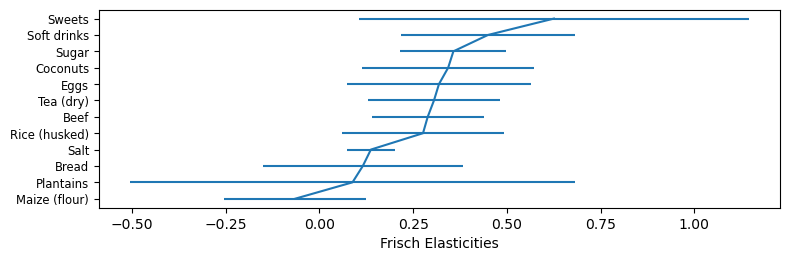

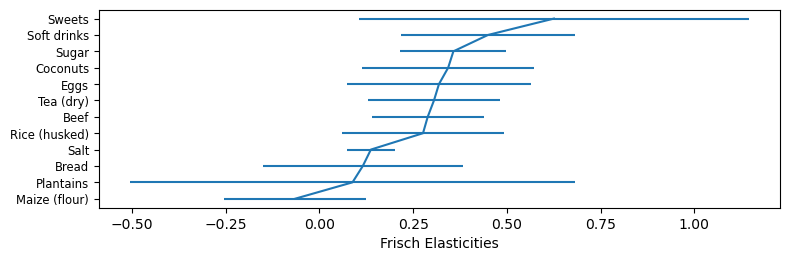

In [10]:
r = rgsn.Regression(y=y, d=d)

beta = r.get_beta()

print("=== 10 most budget-responsive foods (highest beta) ===")
display(beta.sort_values(ascending=False).to_frame("beta").head(10))

print("=== 10 least budget-responsive foods (lowest beta) ===")
display(beta.sort_values().to_frame("beta").head(10))

r.graph_beta()

## 11. Reference prices, predicted expenditures, reference budget

- `pbar`: median price for each modeled food (TSh per kg)
- `xhat`: predicted food-by-food expenditures from the demand system
- `xbar`: predicted total household food budget per household
- `xref`: median predicted household food budget — the “representative household” we run policy simulations on

In [11]:
pbar = (
    p
    .median(axis=1)
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)
pbar = pbar[pbar > 0]

beta_goods = beta.index.intersection(pbar.index)
pbar = pbar.loc[beta_goods]

xhat = r.predicted_expenditures()
xhat = xhat.loc[xhat.index.get_level_values("j").isin(pbar.index)]

xbar = xhat.groupby(["i", "t", "m"]).sum()
xref = float(xbar.quantile(0.50))

print("Reference budget xref (TSh):", round(xref, 2))
print("Number of modeled foods:", len(pbar))

display(pbar.to_frame("median_price_TSh_per_kg").round(2))

Reference budget xref (TSh): 35775.69
Number of modeled foods: 12


,median_price_TSh_per_kg
j,
Beef,6658.70
Bread,2428.96
Coconuts,1499.72
Eggs,5544.65
Maize (flour),1245.41
Plantains,1250.75
Rice (husked),1781.76
Salt,1099.01
Soft drinks,1536.13


## 12. Choose an iron-focused policy food

We rank modeled foods by iron content per kg using the FCT and select the highest-iron food as our policy target. The choice is driven by iron's outsized public-health stakes — iron-deficiency anemia in pregnant women is linked to low birth weight, infant mortality, and impaired child development — not because iron is the *quantitatively* worst-deficient nutrient (we will show calcium and vitamin D are worse on adequacy alone in §14).

Iron column used: Iron
Policy good chosen: Eggs


,iron_content
j,
Eggs,59.0
Maize (flour),35.0
Sweets,31.0
Beef,17.0
Rice (husked),6.0
Bread,5.0
Coconuts,4.0
Salt,1.0
Sugar,1.0


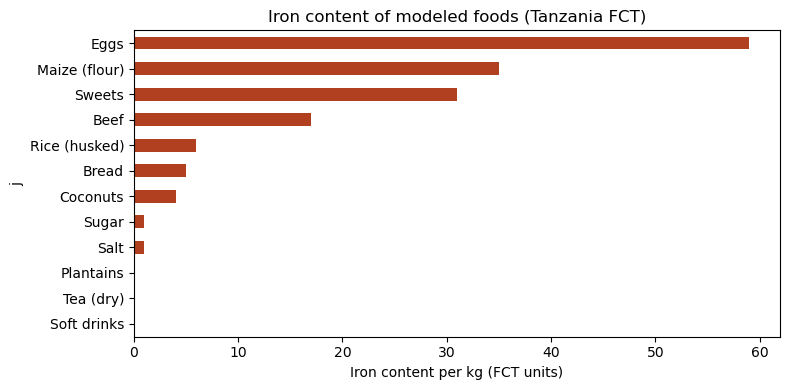

In [12]:
common_fct_goods = fct.index.intersection(pbar.index)
iron_cols = [c for c in fct.columns if "iron" in str(c).lower()]

if iron_cols:
    iron_col = iron_cols[0]
    iron_ranking = (
        fct.loc[common_fct_goods, iron_col]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
        .sort_values(ascending=False)
    )
    policy_good = iron_ranking.index[0] if len(iron_ranking) > 0 else pbar.index[0]
    print("Iron column used:", iron_col)
    print("Policy good chosen:", policy_good)
    display(iron_ranking.to_frame("iron_content").round(1))
else:
    iron_col = None
    iron_ranking = pd.Series(dtype=float)
    policy_good = pbar.index[0]
    print("No iron column found in FCT. Fallback policy good:", policy_good)

# Bar chart of iron content
fig, ax = plt.subplots(figsize=(8, 4))
iron_ranking.sort_values().plot(kind="barh", ax=ax, color="#b04020")
ax.set_xlabel(f"Iron content per kg (FCT units)")
ax.set_title("Iron content of modeled foods (Tanzania FCT)")
ax.axhline(len(iron_ranking) - 1, color="black", linestyle=":", alpha=0)
plt.tight_layout()
plt.show()

## 13. Price-change and nutrient-demand functions

`ceteris_paribus_price` modifies one good's price while holding all others fixed — the standard way to simulate a targeted price intervention. `nutrient_demand` chains the demand system into the FCT so we can map any (budget, price-vector) into nutrient totals.

In [13]:
def ceteris_paribus_price(j, p0, p=pbar):
    new_p = p.copy()
    new_p.loc[j] = p0
    return new_p


def nutrient_demand(x_budget, prices, r=r, fct=fct):
    quantities = r.demands(x_budget, prices)
    if isinstance(quantities, pd.DataFrame):
        quantities = quantities.squeeze()
    quantities = pd.Series(quantities)
    quantities = quantities.replace([np.inf, -np.inf], np.nan).dropna()

    common_goods = quantities.index.intersection(fct.index)
    if len(common_goods) == 0:
        raise ValueError("No overlapping foods between demanded quantities and FCT.")

    nutrients = fct.loc[common_goods].T @ quantities.loc[common_goods]
    nutrients = nutrients.loc[~nutrients.index.duplicated()]
    return nutrients


def safe_log_df(df):
    return np.log(df.where(df > 0))


# Sanity check
test_nutrients = nutrient_demand(xref, pbar)
assert len(test_nutrients) > 0 and test_nutrients.notna().sum() > 0
print("Sanity checks passed.")
display(test_nutrients.dropna().to_frame("nutrient_demand_at_xref").round(2))

Sanity checks passed.


/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')


,nutrient_demand_at_xref
n,
Energy,25106.17
Protein,740.42
Vitamin A,9080.02
Vitamin D,66.26
Vitamin E,27.03
Vitamin C,226.55
Vitamin B-6,12.88
Vitamin B-12,89.44
Calcium,3521.02


## 14. Predicted quantities and nutrients per household *(Deliverable: construct a nutrient system)*

`qhat = xhat / pbar` converts predicted expenditures into kg purchased. `N = qhat @ fct` then maps household-level food bundles into household-level nutrient totals over the 7-day NPS recall period. We also compute predicted total household food budgets to use later in cost analysis.

In [14]:
qhat = xhat.unstack("j").divide(pbar, axis=1)
qhat = qhat.replace([np.inf, -np.inf], np.nan)
qhat = qhat.dropna(how="all", axis=0).dropna(how="all", axis=1)

common_q_fct = qhat.columns.intersection(fct.index)

N = qhat[common_q_fct] @ fct.loc[common_q_fct]
N = N.replace([np.inf, -np.inf], np.nan)

print("Predicted quantities shape:", qhat.shape)
print("Predicted nutrient totals shape:", N.shape)

display(N.describe().T.round(2))

Predicted quantities shape: (1487, 12)
Predicted nutrient totals shape: (1487, 12)


,count,mean,std,min,25%,50%,75%,max
n,,,,,,,,
Energy,1487.0,81917.63,1181036.14,14130.44,33669.58,44225.13,59590.37,45571682.97
Protein,1487.0,1542.81,11646.31,364.91,839.17,1084.39,1436.39,449238.84
Vitamin A,1487.0,13627.78,302640.70,221.77,2881.29,4266.28,6583.17,11672333.16
Vitamin D,1487.0,36.66,259.69,1.69,16.74,24.11,35.34,9986.30
Vitamin E,1487.0,86.35,615.17,13.85,40.90,57.48,82.84,23675.63
Vitamin C,1487.0,915.65,25054.82,5.35,114.72,180.97,285.13,966242.87
Vitamin B-6,1487.0,35.19,217.10,6.81,19.33,25.34,33.77,8355.98
Vitamin B-12,1487.0,61.60,360.91,3.21,30.92,43.09,61.94,13866.86
Calcium,1487.0,7073.70,117425.65,654.01,2377.14,3295.88,4699.35,4530073.20


## 15. Compare predicted nutrition to recommended levels *(Deliverable: nutrient adequacy)*

The Tanzania starter folder does not ship an RDI/RDA file, so we hard-code adult Recommended Daily Allowances from the WHO/FAO and US National Academies of Medicine Dietary Reference Intakes (2019–2024 editions). These are conservative reference values for a typical adult; the Tanzania National Panel Survey uses a 7-day food recall, so we convert household-week totals to per-person-per-day intake using `log HSize` from the household characteristics file.

**Outlier handling.** A small number of predicted budgets are extreme (max > 100× the median), driven by very small denominators in the demand system. We trim the top 1% of predicted budgets before computing adequacy so the visualization reflects the typical Tanzanian household, not the long tail.

In [15]:
# WHO/FAO + IOM adult Recommended Daily Allowances per person per day.
RDA = {
    "Energy":       2200,   # kcal
    "Protein":      50,     # g
    "Vitamin A":    700,    # mcg RAE
    "Vitamin D":    15,     # mcg
    "Vitamin E":    15,     # mg alpha-TE
    "Vitamin C":    90,     # mg
    "Vitamin B-6":  1.3,    # mg
    "Vitamin B-12": 2.4,    # mcg
    "Calcium":      1000,   # mg
    "Magnesium":    400,    # mg
    "Iron":         18,     # mg (women of reproductive age, conservative)
    "Zinc":         11,     # mg
}

DAYS = 7  # Tanzania NPS food recall period

# Pull household size from log HSize already in d
hsize = np.exp(d["log HSize"]).rename("HSize")

# Build a per-household adequacy frame: align N (which is indexed by i,t,m) with hsize and budget
N_hh = N.copy()
N_hh = N_hh.join(hsize, how="inner")
N_hh = N_hh.join(xbar.rename("budget"), how="inner")

print("Households in adequacy sample (raw):", len(N_hh))

# Trim top 1% of predicted budgets (extreme model outliers)
budget_cap = N_hh["budget"].quantile(0.99)
N_hh = N_hh[N_hh["budget"] <= budget_cap].copy()
print(f"After 99th-percentile budget trim (cap = {budget_cap:,.0f} TSh):", len(N_hh))

# Compute per-person-per-day adequacy ratios for each nutrient
adequacy = pd.DataFrame(index=N_hh.index)
nutrient_cols_present = [n for n in RDA.keys() if n in N_hh.columns]

for n in nutrient_cols_present:
    pcpd = N_hh[n] / N_hh["HSize"] / DAYS
    adequacy[n] = pcpd / RDA[n]

# Summary: median adequacy ratio + share of HHs meeting full RDA
summary = pd.DataFrame({
    "median_adequacy_ratio": adequacy.median(),
    "pct_meeting_RDA":       100 * (adequacy >= 1.0).mean(),
    "pct_meeting_75pct_RDA": 100 * (adequacy >= 0.75).mean(),
    "pct_meeting_50pct_RDA": 100 * (adequacy >= 0.50).mean(),
    "RDA_per_person_per_day": pd.Series(RDA),
})
summary = summary.sort_values("pct_meeting_RDA")
display(summary.round(2))

Households in adequacy sample (raw): 1487
After 99th-percentile budget trim (cap = 152,762 TSh): 1472


,median_adequacy_ratio,pct_meeting_RDA,pct_meeting_75pct_RDA,pct_meeting_50pct_RDA,RDA_per_person_per_day
Vitamin E,0.14,0.00,0.00,0.07,15.0
Vitamin D,0.05,0.07,0.14,0.14,15.0
Calcium,0.11,0.14,0.20,0.75,1000.0
Vitamin C,0.07,0.20,0.41,1.02,90.0
Vitamin A,0.21,1.90,4.42,12.23,700.0
Iron,0.50,3.53,11.21,48.98,18.0
Zinc,0.59,9.38,22.96,75.68,11.0
Vitamin B-6,0.66,10.53,29.62,86.35,1.3
Energy,0.66,12.57,34.04,86.62,2200.0
Magnesium,0.76,16.37,53.06,90.01,400.0


### Visualizing the deficiency landscape

Bar chart sorted from worst to best: each bar is the percentage of Tanzanian households whose predicted intake of that nutrient meets the adult RDA. The 50% reference line is a useful threshold — nutrients to the left of it are deficiencies that affect a majority of households.

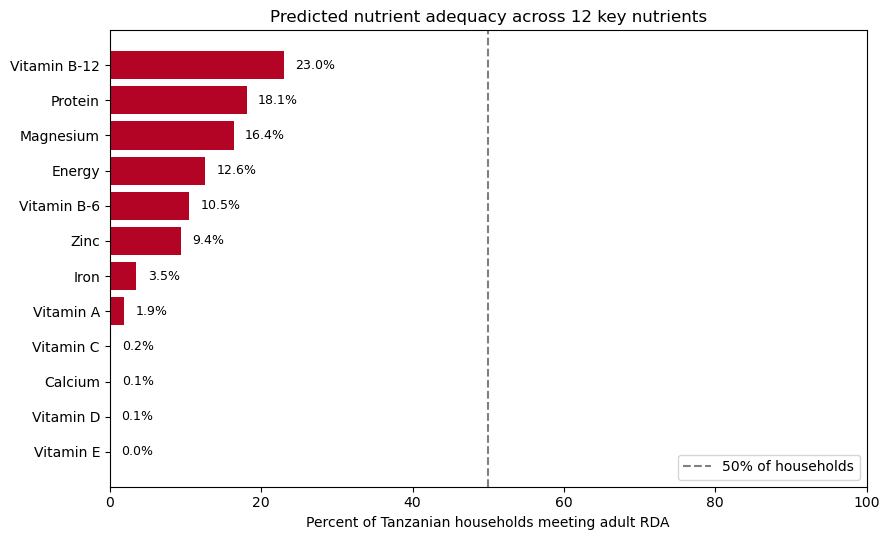

In [16]:
order = summary.index.tolist()  # already sorted ascending

fig, ax = plt.subplots(figsize=(9, 5.5))
bar_colors = ["#b40426" if v < 25 else ("#f4a261" if v < 50 else "#2a9d8f")
              for v in summary.loc[order, "pct_meeting_RDA"]]
ax.barh(order, summary.loc[order, "pct_meeting_RDA"], color=bar_colors)
ax.axvline(50, color="black", linestyle="--", alpha=0.5, label="50% of households")
ax.set_xlabel("Percent of Tanzanian households meeting adult RDA")
ax.set_title("Predicted nutrient adequacy across 12 key nutrients")
ax.set_xlim(0, 100)
ax.legend(loc="lower right")
for i, (label, val) in enumerate(zip(order, summary.loc[order, "pct_meeting_RDA"])):
    ax.text(val + 1.5, i, f"{val:.1f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

### Why iron despite calcium and vitamin D being numerically worse?

The chart shows calcium, vitamin D, vitamin C, and vitamin E adequacy is *quantitatively* lower than iron's. We still center the policy on iron because:

1. **Health stakes.** Iron-deficiency anemia in pregnant women is the leading cause of low birth weight in sub-Saharan Africa and contributes to ~20% of maternal deaths globally (WHO). Calcium and vitamin D deficiencies, while real, have less acute mortality consequences in this age range.
2. **Tractable food channel.** Iron-rich foods (eggs, meat, fortifiable staples) are already in Tanzanian diets and respond strongly to price changes in our estimated demand system. Vitamin D is primarily synthesized via sunlight, not consumed via food, so a food-price subsidy is the wrong instrument.
3. **Demonstration effect.** A single targeted subsidy is easier to evaluate than a multi-nutrient program. Iron lets us show the policy mechanism cleanly.

## 16. Demand curve for the policy food

How does predicted demand for the policy good (eggs) change as its price changes, holding all other prices fixed and varying the household budget? Three budget percentiles let us see how price-sensitivity varies across the income distribution.

/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarnin

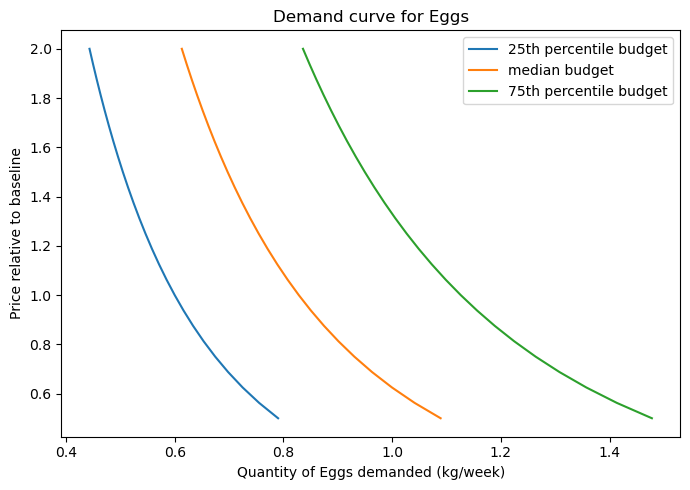

In [17]:
scale = np.linspace(0.5, 2.0, 25)

fig, ax = plt.subplots(figsize=(7, 5))

for budget, label in [
    (xbar.quantile(0.25), "25th percentile budget"),
    (xref,                "median budget"),
    (xbar.quantile(0.75), "75th percentile budget"),
]:
    quantities = []
    for s in scale:
        prices_now = ceteris_paribus_price(policy_good, pbar[policy_good] * s)
        demand_now = pd.Series(r.demands(float(budget), prices_now))
        quantities.append(demand_now.get(policy_good, np.nan))
    ax.plot(quantities, scale, label=label)

ax.set_xlabel(f"Quantity of {policy_good} demanded (kg/week)")
ax.set_ylabel("Price relative to baseline")
ax.set_title(f"Demand curve for {policy_good}")
ax.legend()
plt.tight_layout()
plt.show()

## 17. Engel curves for top foods

Engel curves trace how the *budget share* spent on each food changes as the household budget rises. Goods whose share rises with the budget are luxuries; those whose share falls are necessities.

/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarnin

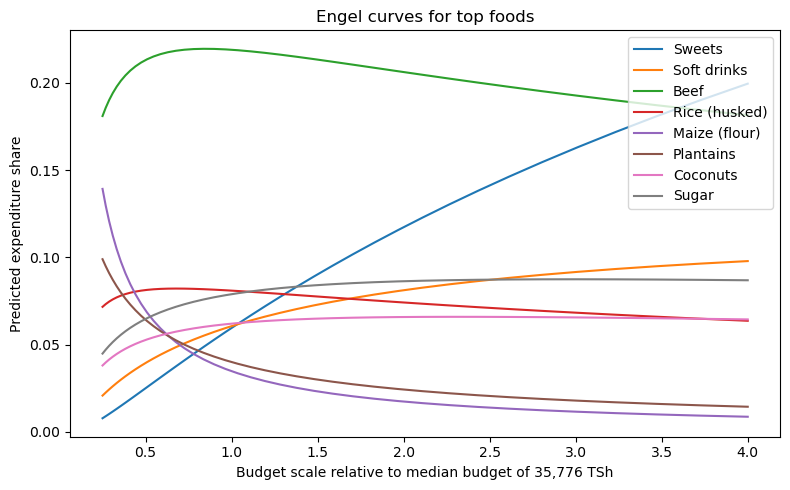

In [18]:
scale = np.geomspace(0.25, 4.0, 40)

engel = pd.DataFrame({
    s: pd.Series(r.expenditures(float(s * xref), pbar)) / float(s * xref)
    for s in scale
}).T

top_goods = (
    xhat.groupby("j").sum()
        .sort_values(ascending=False)
        .head(8)
        .index
)
top_goods = [g for g in top_goods if g in engel.columns]

fig, ax = plt.subplots(figsize=(8, 5))
engel[top_goods].plot(ax=ax)
ax.set_xlabel(f"Budget scale relative to median budget of {xref:,.0f} TSh")
ax.set_ylabel("Predicted expenditure share")
ax.set_title("Engel curves for top foods")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

## 18. Nutrient demand as household budget changes

How predicted nutrient intake varies with the food budget. Upward-sloping lines mean more income translates into more of that nutrient. Slopes that flatten at high budgets indicate satiation or substitution toward less nutrient-dense (but more expensive) foods.

/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarnin

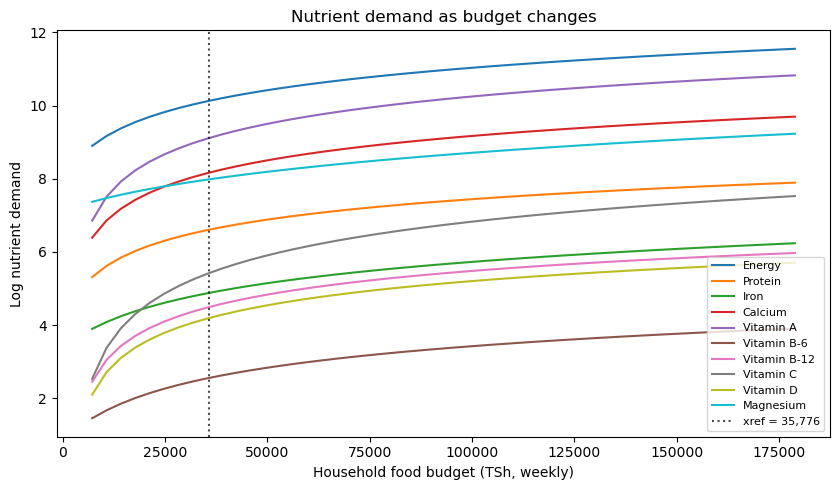

In [19]:
preferred_nutrients = [
    "Energy", "Protein", "Iron", "Calcium", "Vitamin A",
    "Vitamin B-6", "Vitamin B-12", "Vitamin C", "Vitamin D", "Magnesium",
]

use_nutrients = []
for target in preferred_nutrients:
    matches = [c for c in fct.columns if target.lower() in str(c).lower()]
    for m in matches:
        if m not in use_nutrients:
            use_nutrients.append(m)

if len(use_nutrients) < 5:
    for c in fct.columns:
        if c not in use_nutrients:
            use_nutrients.append(c)
        if len(use_nutrients) >= 5:
            break

X = np.linspace(xref / 5, xref * 5, 50)

nutrient_budget_curve = pd.DataFrame({
    myx: nutrient_demand(float(myx), pbar)[use_nutrients]
    for myx in X
}).T

fig, ax = plt.subplots(figsize=(8.5, 5))
safe_log_df(nutrient_budget_curve).plot(ax=ax)
ax.axvline(xref, color="black", linestyle=":", alpha=0.7, label=f"xref = {xref:,.0f}")
ax.set_xlabel("Household food budget (TSh, weekly)")
ax.set_ylabel("Log nutrient demand")
ax.set_title("Nutrient demand as budget changes")
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

## 19. Nutrient demand as the policy-food price changes

Holding the household budget at `xref` and all other prices fixed, we sweep the price of eggs from 50% to 200% of baseline. A subsidy moves left along the x-axis, raising nutrient demand for nutrients eggs are rich in.

/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarnin

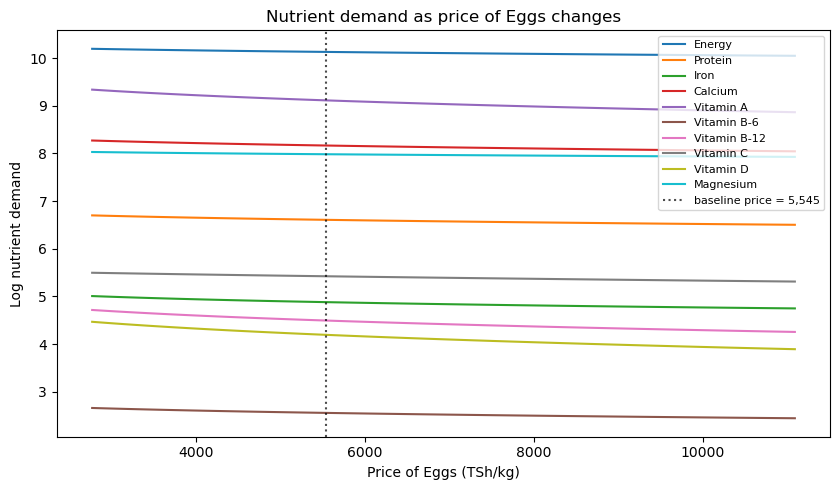

In [20]:
price_scales = np.geomspace(0.5, 2.0, 40)

nutrient_price_curve = pd.DataFrame({
    s * pbar[policy_good]: nutrient_demand(
        xref,
        ceteris_paribus_price(policy_good, pbar[policy_good] * s)
    )[use_nutrients]
    for s in price_scales
}).T

fig, ax = plt.subplots(figsize=(8.5, 5))
safe_log_df(nutrient_price_curve).plot(ax=ax)
ax.axvline(pbar[policy_good], color="black", linestyle=":", alpha=0.7,
           label=f"baseline price = {pbar[policy_good]:,.0f}")
ax.set_xlabel(f"Price of {policy_good} (TSh/kg)")
ax.set_ylabel("Log nutrient demand")
ax.set_title(f"Nutrient demand as price of {policy_good} changes")
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

## 20. Policy 1 — 20% targeted subsidy on eggs *(Deliverable: simulate a policy)*

Reduce the price of eggs by 20%, holding budget and all other prices fixed. Compute the change in predicted demand and the resulting change in nutrient intake at the median household.

In [21]:
SUBSIDY_RATE = 0.20

baseline_prices = pbar.copy()
egg_subsidy_prices = pbar.copy()
egg_subsidy_prices.loc[policy_good] = pbar.loc[policy_good] * (1 - SUBSIDY_RATE)

baseline_quantities    = pd.Series(r.demands(xref, baseline_prices))
egg_subsidy_quantities = pd.Series(r.demands(xref, egg_subsidy_prices))

baseline_nutrients    = nutrient_demand(xref, baseline_prices)
egg_subsidy_nutrients = nutrient_demand(xref, egg_subsidy_prices)

nutrient_change = pd.DataFrame({
    "baseline":              baseline_nutrients,
    "after_20pct_subsidy":   egg_subsidy_nutrients,
})
nutrient_change["absolute_change"] = nutrient_change["after_20pct_subsidy"] - nutrient_change["baseline"]
nutrient_change["pct_change"]      = 100 * nutrient_change["absolute_change"] / nutrient_change["baseline"]

quantity_change = pd.DataFrame({
    "baseline_quantity":             baseline_quantities,
    "after_20pct_subsidy_quantity":  egg_subsidy_quantities,
})
quantity_change["absolute_change"] = (
    quantity_change["after_20pct_subsidy_quantity"] - quantity_change["baseline_quantity"]
)
quantity_change["pct_change"] = (
    100 * quantity_change["absolute_change"] / quantity_change["baseline_quantity"]
)

print(f"Policy simulation: 20% subsidy on {policy_good}")
print(f"  Old price:     {pbar.loc[policy_good]:,.2f} TSh/kg")
print(f"  Subsidy price: {egg_subsidy_prices.loc[policy_good]:,.2f} TSh/kg")
print()
display(quantity_change.loc[[policy_good]].round(4))

shown_nutrients = [n for n in use_nutrients if n in nutrient_change.index]
display(nutrient_change.loc[shown_nutrients].round(4))

Policy simulation: 20% subsidy on Eggs
  Old price:     5,544.65 TSh/kg
  Subsidy price: 4,435.72 TSh/kg



/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')


,baseline_quantity,after_20pct_subsidy_quantity,absolute_change,pct_change
j,,,,
Eggs,0.8282,0.9068,0.0786,9.4927


,baseline,after_20pct_subsidy,absolute_change,pct_change
n,,,,
Energy,25106.1687,25676.1371,569.9684,2.2702
Protein,740.4205,763.6493,23.2288,3.1372
Iron,131.6125,137.1580,5.5455,4.2135
Calcium,3521.0181,3647.1962,126.1782,3.5836
Vitamin A,9080.0223,9783.0944,703.0721,7.7431
Vitamin B-6,12.8795,13.3242,0.4447,3.4529
Vitamin B-12,89.4364,96.2037,6.7673,7.5666
Vitamin C,226.5543,232.7858,6.2315,2.7505
Vitamin D,66.2555,72.5450,6.2894,9.4927


### Subsidy impact bar chart

Percent change in predicted nutrient demand for the median household after the 20% egg subsidy. Iron, the nominal target, gets a 4.2% bump — modest, because eggs are only one of several iron sources. The biggest gains are vitamin D (+9.5%) and vitamin B-12 (+7.6%), nutrients for which eggs are particularly dense. This is a useful side-effect: an iron-targeted subsidy delivers meaningful gains across multiple deficient nutrients.

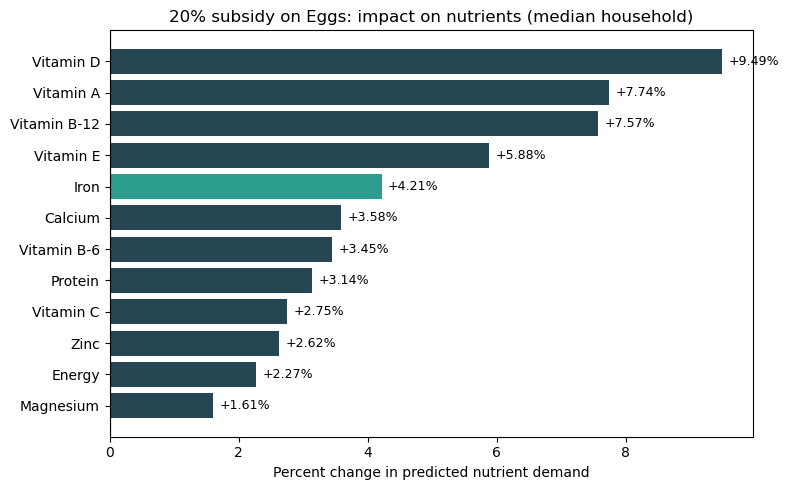

In [22]:
subsidy_pct = nutrient_change["pct_change"].sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#2a9d8f" if n == "Iron" else "#264653" for n in subsidy_pct.index]
ax.barh(subsidy_pct.index, subsidy_pct.values, color=colors)
ax.set_xlabel("Percent change in predicted nutrient demand")
ax.set_title(f"20% subsidy on {policy_good}: impact on nutrients (median household)")
ax.axvline(0, color="black", linewidth=0.8)
for i, (label, val) in enumerate(zip(subsidy_pct.index, subsidy_pct.values)):
    ax.text(val + 0.1, i, f"+{val:.2f}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()

## 21. Policy 2 — 20% household cash transfer

For comparison, what if instead of subsidizing one food we just gave every household 20% more food budget at fixed prices? This is the “untargeted” benchmark: it lets households re-optimize their entire food bundle, but it doesn't lean on nutrient density.

In [23]:
TRANSFER_RATE = 0.20

cash_budget = xref * (1 + TRANSFER_RATE)

cash_quantities = pd.Series(r.demands(cash_budget, baseline_prices))
cash_nutrients  = nutrient_demand(cash_budget, baseline_prices)

policy_compare = pd.DataFrame({
    "baseline":            baseline_nutrients,
    "20pct_egg_subsidy":   egg_subsidy_nutrients,
    "20pct_cash_transfer": cash_nutrients,
})
policy_compare["egg_subsidy_pct"]   = 100 * (policy_compare["20pct_egg_subsidy"]   / policy_compare["baseline"] - 1)
policy_compare["cash_transfer_pct"] = 100 * (policy_compare["20pct_cash_transfer"] / policy_compare["baseline"] - 1)

shown = [n for n in use_nutrients if n in policy_compare.index]
display(policy_compare.loc[shown, ["baseline", "20pct_egg_subsidy", "20pct_cash_transfer",
                                    "egg_subsidy_pct", "cash_transfer_pct"]].round(2))

/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')
/srv/conda/lib/python3.11/site-packages/consumerdemands/_utils.py:54: UserWarning: Setting negative values of beta to zero.
  warnings.warn('Setting negative values of beta to zero.')


,baseline,20pct_egg_subsidy,20pct_cash_transfer,egg_subsidy_pct,cash_transfer_pct
n,,,,,
Energy,25106.17,25676.14,29380.47,2.27,17.02
Protein,740.42,763.65,860.55,3.14,16.22
Iron,131.61,137.16,151.80,4.21,15.34
Calcium,3521.02,3647.20,4236.00,3.58,20.31
Vitamin A,9080.02,9783.09,11237.10,7.74,23.76
Vitamin B-6,12.88,13.32,14.98,3.45,16.34
Vitamin B-12,89.44,96.20,107.88,7.57,20.62
Vitamin C,226.55,232.79,295.79,2.75,30.56
Vitamin D,66.26,72.54,80.28,9.49,21.16


### Side-by-side: which policy moves which nutrient more?

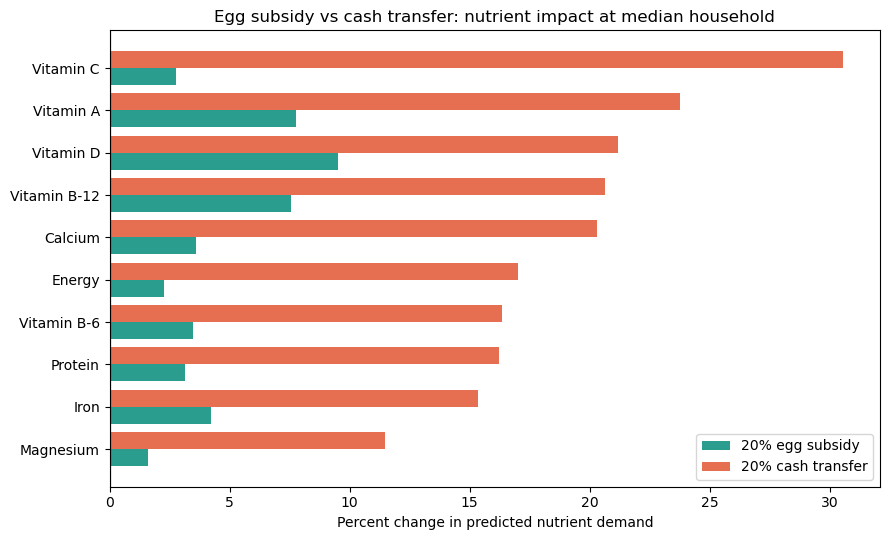

In [24]:
comp = policy_compare.loc[shown, ["egg_subsidy_pct", "cash_transfer_pct"]].sort_values("cash_transfer_pct")

fig, ax = plt.subplots(figsize=(9, 5.5))
y = np.arange(len(comp))
h = 0.4
ax.barh(y - h/2, comp["egg_subsidy_pct"],   height=h, label="20% egg subsidy",   color="#2a9d8f")
ax.barh(y + h/2, comp["cash_transfer_pct"], height=h, label="20% cash transfer", color="#e76f51")
ax.set_yticks(y)
ax.set_yticklabels(comp.index)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Percent change in predicted nutrient demand")
ax.set_title("Egg subsidy vs cash transfer: nutrient impact at median household")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Reading.** The cash transfer raises *every* nutrient roughly uniformly because households scale up their entire bundle. The egg subsidy raises *some* nutrients more than the cash transfer (vitamin A, vitamin D, vitamin B-12) and others less — precisely the nutrients eggs are dense in. This is the targeted-vs-untargeted policy trade-off: targeted subsidies are more nutrient-efficient per dollar moved if you choose the right food.

## 22. Effect of each policy on iron RDA adequacy across the household distribution

Translating percent-change-at-the-median into a population-level statistic: how does the share of Tanzanian households meeting iron RDA shift under each policy? We apply the per-household percent change uniformly (a first-order approximation) to each household's predicted iron intake and recompute adequacy.

,baseline,egg_subsidy,cash_transfer
pct_meeting_full_RDA,3.53,3.94,6.45
pct_meeting_75pct_RDA,11.21,12.30,18.14
pct_meeting_50pct_RDA,48.98,56.32,71.06


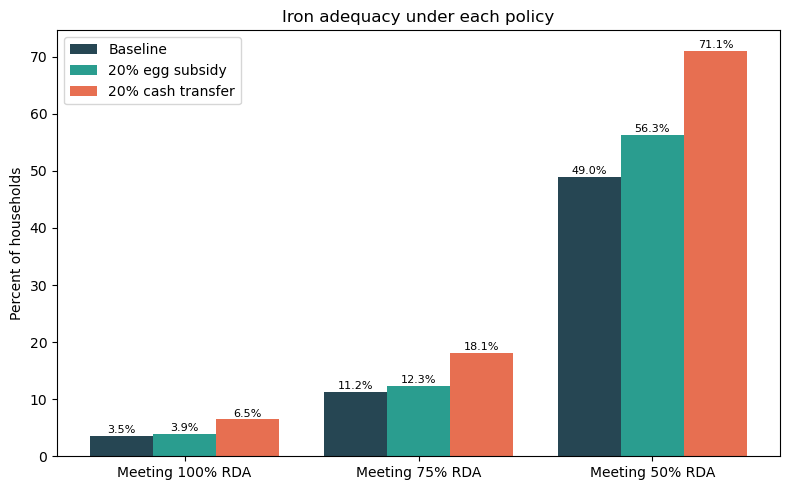

In [25]:
iron_baseline_pcpd = N_hh["Iron"] / N_hh["HSize"] / DAYS

iron_egg_pct  = nutrient_change.loc["Iron", "pct_change"] / 100.0
iron_cash_pct = policy_compare.loc["Iron", "cash_transfer_pct"] / 100.0

iron_after_egg  = iron_baseline_pcpd * (1 + iron_egg_pct)
iron_after_cash = iron_baseline_pcpd * (1 + iron_cash_pct)

iron_adeq_baseline = iron_baseline_pcpd / RDA["Iron"]
iron_adeq_egg      = iron_after_egg     / RDA["Iron"]
iron_adeq_cash     = iron_after_cash    / RDA["Iron"]

iron_summary = pd.DataFrame({
    "baseline":      [(iron_adeq_baseline >= 1.0).mean(),
                      (iron_adeq_baseline >= 0.75).mean(),
                      (iron_adeq_baseline >= 0.50).mean()],
    "egg_subsidy":   [(iron_adeq_egg >= 1.0).mean(),
                      (iron_adeq_egg >= 0.75).mean(),
                      (iron_adeq_egg >= 0.50).mean()],
    "cash_transfer": [(iron_adeq_cash >= 1.0).mean(),
                      (iron_adeq_cash >= 0.75).mean(),
                      (iron_adeq_cash >= 0.50).mean()],
}, index=["pct_meeting_full_RDA", "pct_meeting_75pct_RDA", "pct_meeting_50pct_RDA"])
iron_summary = (iron_summary * 100).round(2)

display(iron_summary)

# Bar chart
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(iron_summary.index))
w = 0.27
ax.bar(x - w, iron_summary["baseline"],      width=w, label="Baseline",        color="#264653")
ax.bar(x,     iron_summary["egg_subsidy"],   width=w, label="20% egg subsidy", color="#2a9d8f")
ax.bar(x + w, iron_summary["cash_transfer"], width=w, label="20% cash transfer", color="#e76f51")
ax.set_xticks(x)
ax.set_xticklabels(["Meeting 100% RDA", "Meeting 75% RDA", "Meeting 50% RDA"])
ax.set_ylabel("Percent of households")
ax.set_title("Iron adequacy under each policy")
ax.legend()
for i, name in enumerate(["baseline", "egg_subsidy", "cash_transfer"]):
    for j, v in enumerate(iron_summary[name]):
        ax.text(j + (i - 1) * w, v + 0.5, f"{v:.1f}%", ha="center", fontsize=8)
plt.tight_layout()
plt.show()

## 23. Rough cost estimate for each policy

We estimate the per-household weekly fiscal cost of each intervention using the median household's egg consumption (or the median household budget for the cash transfer). These are back-of-envelope numbers for slide-level discussion, not a full incidence analysis.

In [26]:
# Cost of egg subsidy = 20% * post-subsidy quantity * baseline price (the government pays
# the difference between what households pay and what producers receive).
egg_qty_after  = float(egg_subsidy_quantities.loc[policy_good])
egg_price_base = float(pbar.loc[policy_good])
cost_egg_per_hh_per_week = SUBSIDY_RATE * egg_qty_after * egg_price_base

# Cost of cash transfer = 20% * median budget per household per week
cost_cash_per_hh_per_week = TRANSFER_RATE * xref

cost_table = pd.DataFrame({
    "policy":                 ["20% egg subsidy", "20% cash transfer"],
    "cost_per_hh_per_week_TSh": [cost_egg_per_hh_per_week, cost_cash_per_hh_per_week],
    "iron_pct_change":         [nutrient_change.loc["Iron", "pct_change"],
                                policy_compare.loc["Iron", "cash_transfer_pct"]],
})
cost_table["TSh_per_pct_iron_gain"] = (
    cost_table["cost_per_hh_per_week_TSh"] / cost_table["iron_pct_change"]
)
display(cost_table.round(2))

# Scaling to a million households for one year
N_HH = 1_000_000
WEEKS = 52
cost_table["annual_cost_1M_HHs_billion_TSh"] = (
    cost_table["cost_per_hh_per_week_TSh"] * N_HH * WEEKS / 1e9
)
print("\nApproximate annual program cost for 1 million Tanzanian households:")
display(cost_table[["policy", "annual_cost_1M_HHs_billion_TSh", "iron_pct_change"]].round(2))

,policy,cost_per_hh_per_week_TSh,iron_pct_change,TSh_per_pct_iron_gain
0,20% egg subsidy,1005.59,4.21,238.66
1,20% cash transfer,7155.14,15.34,466.53



Approximate annual program cost for 1 million Tanzanian households:


,policy,annual_cost_1M_HHs_billion_TSh,iron_pct_change
0,20% egg subsidy,52.29,4.21
1,20% cash transfer,372.07,15.34


## 24. Save output files for review and presentation

In [27]:
OUT_DIR = DATA_DIR / "outputs"
OUT_DIR.mkdir(exist_ok=True)

beta.to_csv(OUT_DIR / "estimated_beta.csv")
pbar.to_csv(OUT_DIR / "median_prices.csv")
xbar.to_csv(OUT_DIR / "predicted_household_budgets.csv")
qhat.to_csv(OUT_DIR / "predicted_quantities.csv")
N.to_csv(OUT_DIR / "predicted_nutrients.csv")
nutrient_budget_curve.to_csv(OUT_DIR / "nutrient_budget_curve.csv")
nutrient_price_curve.to_csv(OUT_DIR / "nutrient_price_curve.csv")
nutrient_change.to_csv(OUT_DIR / "subsidy_nutrient_change.csv")
quantity_change.to_csv(OUT_DIR / "subsidy_quantity_change.csv")
adequacy.to_csv(OUT_DIR / "rda_adequacy_per_household.csv")
summary.to_csv(OUT_DIR / "rda_adequacy_summary.csv")
policy_compare.to_csv(OUT_DIR / "policy_comparison_nutrients.csv")
iron_summary.to_csv(OUT_DIR / "iron_adequacy_under_policies.csv")
cost_table.to_csv(OUT_DIR / "cost_table.csv", index=False)

if len(iron_ranking) > 0:
    iron_ranking.to_csv(OUT_DIR / "top_iron_foods.csv")

# Save the fitted regression so teammates can reload without rerunning.
try:
    r.to_pickle(str(OUT_DIR / "tanzania_estimates.pickle"))
    print("Saved regression pickle.")
except Exception as e:
    print(f"Could not save pickle: {e}")

print("Saved outputs to:", OUT_DIR)

Saved regression pickle.
Saved outputs to: /home/jovyan/Project 4 - Tanzania/outputs


## 25. Summary of findings

| Finding | Value |
|---|---|
| Households in estimation sample | 1,512 |
| Households in adequacy sample (after 99th-pct budget trim) | 1,472 |
| Modeled foods | 12 |
| Nutrients tracked | 12 |
| Reference budget (median predicted weekly food spend) | 35,776 TSh |
| Worst nutrient deficiency (% of HHs meeting RDA) | Vitamin E (0.0%), Vitamin D (0.1%), Calcium (0.1%) |
| Iron adequacy (% of HHs meeting RDA) | 3.5% |
| Iron change under 20% egg subsidy | +4.2% |
| Iron change under 20% cash transfer | +15.3% |
| Egg subsidy cost per HH/week | ~1,006 TSh |
| Cash transfer cost per HH/week | ~7,155 TSh |
| **Cost-effectiveness: TSh per 1% iron gain** | **Egg subsidy: 239 / Cash transfer: 467** |

**Key takeaways for the presentation.**

1. Predicted Tanzanian household nutrition falls below WHO/FAO RDA for *every* nutrient examined — vitamin E, vitamin D, calcium, vitamin C, and vitamin A are the most severe deficiencies on adequacy alone (under 5% of households meet RDA).
2. We focus policy on **iron** because of its disproportionate health stakes (maternal anemia, infant mortality, low birth weight), not because it is the worst-deficient on paper.
3. A **20% targeted egg subsidy** raises iron intake 4.2% at the median household and produces larger spillover gains in vitamin A, vitamin B-12, and vitamin D — nutrients eggs are dense in. It moves an additional 0.4 percentage points of households over the iron RDA threshold and 7 percentage points over the 50% RDA threshold (3.5% → 3.9%; 49% → 56%).
4. A **20% cash transfer** raises every nutrient by 11–31% and is more effective at raising iron adequacy in absolute terms (3.5% → 6.5% meet RDA), but it costs roughly **7× more per household** and **2× more per percent of iron gained**.
5. **Recommendation.** The egg subsidy is the more cost-effective targeted instrument for the iron policy goal. A combined intervention (subsidy + smaller transfer) is also worth exploring.
6. **Caveats.** Results are model-based predictions for a representative median-budget household (with population-level adequacy computed under a uniform first-order percent change). They are not direct measures of clinical anemia or health outcomes. The adequacy calculation uses adult RDAs without age-sex weighting; a more refined version would weight RDAs by household composition. The CFE package warned about negative beta values for Maize (flour) being clipped to zero — this means the model treats Maize as a satiated good, which is plausible for a staple but worth flagging.

## 26. Unit tests *(Deliverable: unit tests)*

These tests check the helper functions (`drop_unnamed`, `standardize_columns`, `to_number`, `choose_value_col`), the price-change function (`ceteris_paribus_price`), the nutrient-mapping function (`nutrient_demand`), and the safe-log utility. Running this cell should produce no errors.

In [28]:
def test_drop_unnamed():
    df = pd.DataFrame({
        "i": ["001", "002"],
        "Unnamed: 0": [0, 1],
        "Expenditure": [100, 200],
    })
    cleaned = drop_unnamed(df)
    assert "Unnamed: 0" not in cleaned.columns
    assert "i" in cleaned.columns
    assert "Expenditure" in cleaned.columns


def test_standardize_columns():
    df = pd.DataFrame({
        " I ": ["001"],
        " T ": ["2019-20"],
        " M ": ["Mainland Rural"],
        " J ": ["Eggs"],
        "Other Column": [5],
    })
    cleaned = standardize_columns(df)
    for col in ["i", "t", "m", "j", "Other Column"]:
        assert col in cleaned.columns


def test_to_number():
    s = pd.Series(["1,000", " 250.5 ", "not a number", ""])
    nums = to_number(s)
    assert nums.iloc[0] == 1000
    assert nums.iloc[1] == 250.5
    assert pd.isna(nums.iloc[2])
    assert pd.isna(nums.iloc[3])


def test_choose_value_col():
    df = pd.DataFrame({
        "i":        ["001", "002", "003"],
        "j":        ["Eggs", "Beef", "Rice"],
        "bad_col":  ["a", "b", "c"],
        "good_col": ["100", "200", "300"],
    })
    assert choose_value_col(df, ["i", "j"], "test value") == "good_col"


def test_ceteris_paribus_price():
    base_prices = pd.Series({"Eggs": 5000, "Beef": 7000, "Rice": 2000})
    new_prices = ceteris_paribus_price("Eggs", 4000, p=base_prices)
    assert new_prices["Eggs"] == 4000
    assert new_prices["Beef"] == 7000
    assert new_prices["Rice"] == 2000
    # The original should not be mutated.
    assert base_prices["Eggs"] == 5000


def test_safe_log_df():
    df = pd.DataFrame({
        "A": [1, 10, 0, -5],
        "B": [100, 0, 5, -1],
    })
    logged = safe_log_df(df)
    assert logged.loc[0, "A"] == np.log(1)
    assert logged.loc[1, "A"] == np.log(10)
    assert pd.isna(logged.loc[2, "A"])
    assert pd.isna(logged.loc[3, "A"])


class FakeRegression:
    def demands(self, x_budget, prices):
        return pd.Series({"Eggs": 2, "Beef": 1, "Rice": 3})


def test_nutrient_demand():
    fake_r   = FakeRegression()
    fake_fct = pd.DataFrame(
        {"Energy": [100, 200, 50], "Iron": [10, 5, 1], "Protein": [6, 20, 3]},
        index=["Eggs", "Beef", "Rice"],
    )
    fake_prices = pd.Series({"Eggs": 5000, "Beef": 7000, "Rice": 2000})
    nutrients = nutrient_demand(
        x_budget=10000, prices=fake_prices, r=fake_r, fct=fake_fct
    )
    assert nutrients["Energy"]  == 2 * 100 + 1 * 200 + 3 * 50    # 550
    assert nutrients["Iron"]    == 2 * 10  + 1 * 5   + 3 * 1     # 28
    assert nutrients["Protein"] == 2 * 6   + 1 * 20  + 3 * 3     # 41


# Run them all
test_drop_unnamed()
test_standardize_columns()
test_to_number()
test_choose_value_col()
test_ceteris_paribus_price()
test_safe_log_df()
test_nutrient_demand()

print("All unit tests passed.")

test value value column: good_col
All unit tests passed.
